In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

In [66]:
df=pd.read_csv("../data/classifications/WineQT.csv")

In [67]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

In [68]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [69]:
X=df.drop(['Id','quality'],axis=1)
y=df["quality"]

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [71]:
n_features = X.shape[1]
n_classes = y.nunique()
n_components = min(n_features, n_classes - 1)
target_names = y.unique().astype(str)

print("n_features:", n_features)
print("n_classes:", n_classes)
print("n_components:", n_components)
target_names

n_features: 11
n_classes: 6
n_components: 5


array(['5', '6', '7', '4', '8', '3'], dtype='<U21')

In [72]:
lda = LDA(n_components=n_components)
lda.fit(X_train, y_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,5
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [73]:
y_pred = lda.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.6157205240174672
              precision    recall  f1-score   support

           5       0.00      0.00      0.00         1
           6       0.33      0.14      0.20         7
           7       0.72      0.77      0.75        97
           4       0.59      0.59      0.59        92
           8       0.38      0.38      0.38        29
           3       0.00      0.00      0.00         3

    accuracy                           0.62       229
   macro avg       0.34      0.31      0.32       229
weighted avg       0.60      0.62      0.61       229



/Users/razzaqismath/Documents/python/tools4hack/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/razzaqismath/Documents/python/tools4hack/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/razzaqismath/Documents/python/tools4hack/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

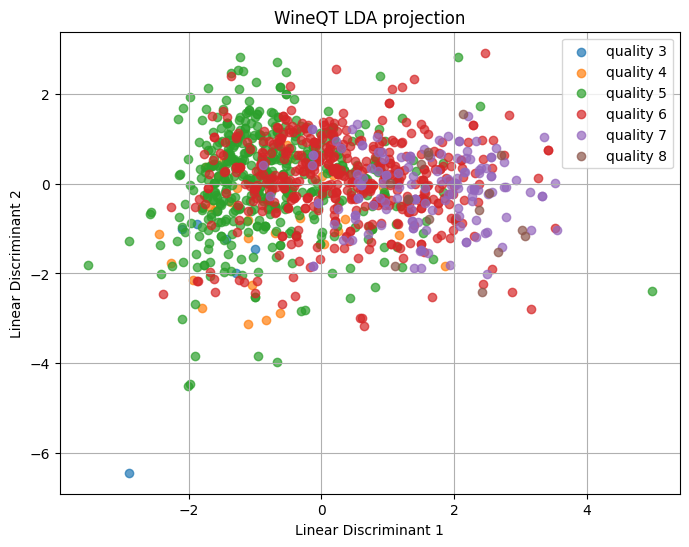

In [77]:
# Transform original high-dimensional data into LDA space
X_lda = lda.transform(X)
plt.figure(figsize=(8, 6))
for class_id, class_name in enumerate(le.classes_):
    plt.scatter(
        X_lda[y_encoded == class_id, 0],
        X_lda[y_encoded == class_id, 1],
        label=f"quality {class_name}",
        alpha=0.7
    )

plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")
plt.title("WineQT LDA projection")
plt.legend()
plt.grid(True)
plt.show()

In [76]:
lda.explained_variance_ratio_

array([0.83275535, 0.08835311, 0.05857723, 0.01468399, 0.00563032])

LDA is trying to find a line (or plane in higher dimensions) that separates classes.
In 2D, imagine:
* You draw a line that tries to split classes apart
* LDA finds the best possible line

Mathematically, it maximizes:
distance between class centers ÷ spread within classes

why it’s still mostly overlap
LDA orders components by importance:

* LD1 → best separation
* LD2 → second best
* LD3+ → weaker and weaker

👉 So if separation was strong:
* You would already see it in LD1/LD2

🔹 What your model is facing
Your features (like acidity, alcohol, etc.):
* Do NOT uniquely determine quality
* Different classes share similar values

Why LDA struggles on your data

Because LDA assumes:
* Linear boundaries
* Gaussian distributions
* Equal covariance (important!)
👉 Your data violates these assumptions
⸻
🔹So how do we build a good classifier?

Since your data overlaps, you need models that can handle:
* Nonlinear boundaries
* Noise
* Complex patterns

🔹 What does “LDA as preprocessing” mean?
It means:
Use LDA to transform your data first, then feed that into another model.

🔹 Why would you do this?
Because LDA:
✅ Reduces dimensionality
✅ Removes noise
✅ Maximizes class separation

So the next model gets:
cleaner, more informative features

Pipeline idea
--------------------
Original Data (high-dimensional, messy)
        ↓
LDA (focus on class separation)
        ↓
Compressed, meaningful features
        ↓
Another model (RF, SVM, etc.)

Example
-----------

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# Step 1: Fit LDA
lda = LinearDiscriminantAnalysis(n_components=n_components)
lda.fit(X_train, y_train)

# Step 2: Transform data
X_train_lda = lda.transform(X_train)
X_test_lda = lda.transform(X_test)

# Step 3: Train another model
rf = RandomForestClassifier()
rf.fit(X_train_lda, y_train)

# Step 4: Predict
y_pred = rf.predict(X_test_lda)


🔹 Why this can help
Without LDA:
Model sees: [acidity, sugar, alcohol, ...]

With LDA:
Model sees:[LD1, LD2, LD3...]
👉 These are optimized combinations of features for separating classes

🔹 When it helps most
LDA preprocessing is useful when:
✅ Many features
✅ Noise in data
✅ Classes somewhat separable
✅ You want fewer dimensions